In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_path = "/content/drive/MyDrive/PlantChatBot/imag/train"
test_path = "/content/drive/MyDrive/PlantChatBot/imag/test"

In [6]:
train_path = "train"
test_path = "test"

In [7]:
train_datagen = ImageDataGenerator(

    rescale=1./255,          # Normalize pixels

    rotation_range=20,       # Data augmentation
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

In [8]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [10]:
print(os.listdir('/content/drive/MyDrive/PlantChatBot'))

['file_renamer.py', 'folder_renamer.py', 'plant_dataset_train.csv', 'plant_dataset_test.csv', 'Untitled (1).ipynb', '.ipynb_checkpoints', 'train', 'test', 'Untitled.ipynb']


In [11]:
train_path = "/content/drive/MyDrive/PlantChatBot/train"
test_path = "/content/drive/MyDrive/PlantChatBot/test"

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 46133 images belonging to 38 classes.


In [14]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 11129 images belonging to 38 classes.


In [15]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 38)


In [16]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [17]:
train_path = "/content/drive/MyDrive/PlantChatBot/train"
test_path = "/content/drive/MyDrive/PlantChatBot/test"

In [18]:
!cp -r /content/drive/MyDrive/PlantChatBot /content/

In [19]:
!du -sh /content/PlantChatBot

1.9G	/content/PlantChatBot


In [20]:
train_path = "/content/PlantChatBot/train"
test_path = "/content/PlantChatBot/test"

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 46133 images belonging to 38 classes.
Found 11129 images belonging to 38 classes.


In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [24]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    steps_per_epoch=200
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 151s 703ms/step - accuracy: 0.1011 - loss: 3.4236 - val_accuracy: 0.0923 - val_loss: 3.3357
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 130s 654ms/step - accuracy: 0.1039 - loss: 3.3700 - val_accuracy: 0.0923 - val_loss: 3.2771
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 129s 647ms/step - accuracy: 0.1069 - loss: 3.3254 - val_accuracy: 0.1809 - val_loss: 3.2765
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 127s 636ms/step - accuracy: 0.1228 - loss: 3.2819 - val_accuracy: 0.1463 - val_loss: 3.2272
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 125s 627ms/step - accuracy: 0.1264 - loss: 3.2643 - val_accuracy: 0.1787 - val_loss: 3.1780
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 125s 628ms/step - accuracy: 0.1381 - loss: 3.2185 - val_accuracy: 0.1597 - val_loss: 3.1374
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 130s 654ms/step - accuracy: 0.1374 - loss: 3.2129 - val_accuracy: 0.2019 - val_loss: 3.1065
Epoch 8/10
 42/200 ━━━━━━━━━━━━━━━━━━━━ 1:00 384ms/step - accuracy: 0.1405 -

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 248ms/step - accuracy: 0.1347 - loss: 3.2308 - val_accuracy: 0.2028 - val_loss: 3.1160
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 130s 644ms/step - accuracy: 0.1392 - loss: 3.2003 - val_accuracy: 0.2083 - val_loss: 3.0861
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 128s 642ms/step - accuracy: 0.1523 - loss: 3.1769 - val_accuracy: 0.1950 - val_loss: 3.0815


In [25]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [26]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=3,
    steps_per_epoch=100,
    validation_steps=10
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 631s 6s/step - accuracy: 0.2109 - loss: 3.1809 - val_accuracy: 0.1094 - val_loss: 3.3582
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 621s 6s/step - accuracy: 0.2856 - loss: 2.8242 - val_accuracy: 0.2250 - val_loss: 3.1868
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 622s 6s/step - accuracy: 0.3363 - loss: 2.5696 - val_accuracy: 0.2344 - val_loss: 2.8476


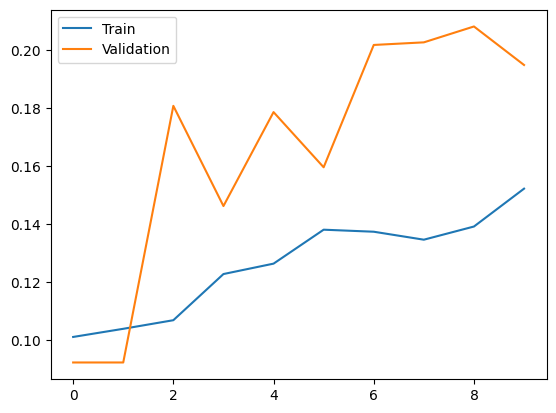

In [27]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'], label='Train')
plt.plot(history_resnet.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

In [29]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)